## Импорты и константы

In [99]:
from pathlib import Path
import pandas as pd
import torch
from torch import nn, optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
from PIL import Image
import torchvision.models as models
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import numpy as np
import os
import random
from torch.backends import cudnn

RANDOM_STATE = 22 

def set_seed(seed=RANDOM_STATE):
    """Фиксирует случайность для всех бэкендов, включая MPS."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    # CUDA (если есть)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.deterministic = True
        cudnn.benchmark = False
    
    # MPS — включаем детерминированные алгоритмы
    if torch.backends.mps.is_available():
        # На MPS cudnn не используется, но torch.set_deterministic работает
        torch.use_deterministic_algorithms(True, warn_only=True)
    
    # Фиксируем hash-рандомизацию Python
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"✅ Seed зафиксирован: {seed}")
    
set_seed(RANDOM_STATE)    

DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
SUBMISSION_PATH = DATA_DIR / "sample_submission.csv"


✅ Seed зафиксирован: 22


## Трансформации

In [100]:
# Статистики ImageNet для нормализации
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# === TRAIN: аугментации и подготовка
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    # сохраняет мелкие детали (крошки, пятна), но дает модели видеть тарелку под разными углами и масштабами
    transforms.RandomHorizontalFlip(p=0.5),  # ломаем ориентацию узора
    transforms.RandomVerticalFlip(p=0.5),
    
    # transforms.RandomRotation(degrees=45),  # поворот заменить на RandomAffine для более естественных искажений
    transforms.RandomAffine(
        degrees=45,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=10,
        fill=0
    ),
    transforms.ColorJitter(  # Освещение (блики)
        brightness=0.3,  # ±30% яркости
        contrast=0.3,  # ±30% контраста
        saturation=0.3,  # ±30% насыщенности
        hue=0.05  # лёгкий сдвиг оттенка
    ),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))     #Blur (заблюренный фон)  
    ], p=0.05),  # шанс применения, лучше маленький, не размоет грязь на тарелках
    
    transforms.ToTensor(),  # обеспечивает правильный формат тензоров [batch_size, каналы(RGB), высота, ширина]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # нормализация
])

# === VAL/TEST: только подготовка (без аугментаций)
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## Dataset для обучения

In [101]:
# torchvision.datasets.ImageFolder автоматически понимает структуру папок:
# data/train/cleaned -> класс 0
# data/train/dirty   -> класс 1
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)

# Смотрим, какие классы он нашел и какие индексы им присвоил
print("Классы:", train_dataset.classes)  # Ожидаем: ['cleaned', 'dirty']
print("Маппинг классов:", train_dataset.class_to_idx)  # Ожидаем: {'cleaned': 0, 'dirty': 1}

Классы: ['cleaned', 'dirty']
Маппинг классов: {'cleaned': 0, 'dirty': 1}


## Кастомный Dataset для теста

In [102]:
class TestImageDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        # Читаем submission CSV, чтобы знать порядок ID и общее количество
        self.df = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Получаем ID и гарантируем формат с ведущими нулями (например, "0005")
        raw_id = self.df.iloc[idx]['id']
        img_id = str(raw_id).zfill(4)

        # 2. Формируем путь с помощью pathlib (оператор /)
        img_path = self.img_dir / f"{img_id}.jpg"

        # 3. Загружаем изображение
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            raise FileNotFoundError(f"Изображение не найдено: {img_path}. Проверьте пути и имена файлов.")

        # 4. Применяем трансформации
        if self.transform:
            image = self.transform(image)

        # 5. Возвращаем тензор и строковый ID (метку не возвращаем, мы её предсказываем)
        return image, img_id


## Маленькая CNN 
3 блока сверток(Conv2D, BatchNorm, RELU, MaxPooling) + Dense (Linear, RELU, Dropout, Linear)

In [103]:
class SimplePlateCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SimplePlateCNN, self).__init__()

        # Блок 1: Извлекаем базовые признаки (края, цвета)
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),  # 224x224 -> 224x224
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 224x224 -> 112x112

            # Блок 2: Извлекаем текстуры (пятна, узоры)
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 112x112 -> 56x56

            # Блок 3: Извлекаем более сложные паттерны (крошки, специфичная грязь)
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56x56 -> 28x28
        )

        # AdaptiveAvgPool2d гарантирует, что на вход классификатора 
        # всегда придет тензор фиксированного размера, независимо от входа.
        # Это также сильно уменьшает количество параметров!
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))  

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64),
            nn.ReLU(),            
            nn.Dropout(p=0.7),  # регуляризация
            nn.Linear(64, num_classes)  # Выход: сырые логиты (без Softmax!)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

### Цикл обучения


In [104]:
def train_model_with_early_stopping(model, train_loader, val_loader, criterion, optimizer,
                                    epochs, device, save_path="best_model.pth",
                                    scheduler=None, patience=5, verbose=False):
    """Обучение с Early Stopping (минимум логов)."""
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    best_val_loss = float('inf')
    epochs_without_improvement = 0

    for epoch in range(epochs):
        # ФАЗА ОБУЧЕНИЯ
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        epoch_train_loss = running_train_loss / train_total
        epoch_train_acc = train_correct / train_total

        # ФАЗА ВАЛИДАЦИИ
        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / val_total
        epoch_val_acc = val_correct / val_total

        if scheduler is not None:
            scheduler.step(epoch_val_loss)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # Печатаем только если verbose=True или каждые 5 эпох
        if verbose or (epoch + 1) % 5 == 0:
            print(
                f"  Epoch {epoch + 1:02d} | Train: {epoch_train_loss:.4f}/{epoch_train_acc:.4f} | Val: {epoch_val_loss:.4f}/{epoch_val_acc:.4f}",
                flush=True)

        # Early Stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            if verbose:
                print(f"  ⏹ Early Stopping на эпохе {epoch + 1}", flush=True)
            break

    model.load_state_dict(torch.load(save_path))
    return model, history

### Функция для отрисовки графиков обучения

In [105]:

def plot_training_history(history):
    """Строит графики Loss и Accuracy для тренировочной и валидационной выборок."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    # LOSS
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)

    axes[0].set_title('Model Loss (Cross-Entropy)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # ACCURACY
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Accuracy', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-o', label='Val Accuracy', linewidth=2, markersize=6)

    axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### Настройка обучения


Fold 1/5
  Epoch 05 | Train: 0.7420/0.5312 | Val: 0.6995/0.3750
  Best Val Acc: 0.7500

Fold 2/5
  Epoch 05 | Train: 0.6480/0.5938 | Val: 0.7128/0.2500
  Epoch 10 | Train: 0.7447/0.4375 | Val: 0.6988/0.5000
  Epoch 15 | Train: 0.6656/0.5312 | Val: 0.6715/0.6250
  Best Val Acc: 0.7500

Fold 3/5
  Epoch 05 | Train: 0.6816/0.5000 | Val: 0.7086/0.5000
  Best Val Acc: 0.7500

Fold 4/5
  Epoch 05 | Train: 0.7088/0.4688 | Val: 0.7205/0.3750
  Best Val Acc: 0.6250

Fold 5/5
  Epoch 05 | Train: 0.7143/0.5000 | Val: 0.6929/0.6250
  Epoch 10 | Train: 0.6220/0.6250 | Val: 0.7219/0.3750
  Best Val Acc: 0.6250


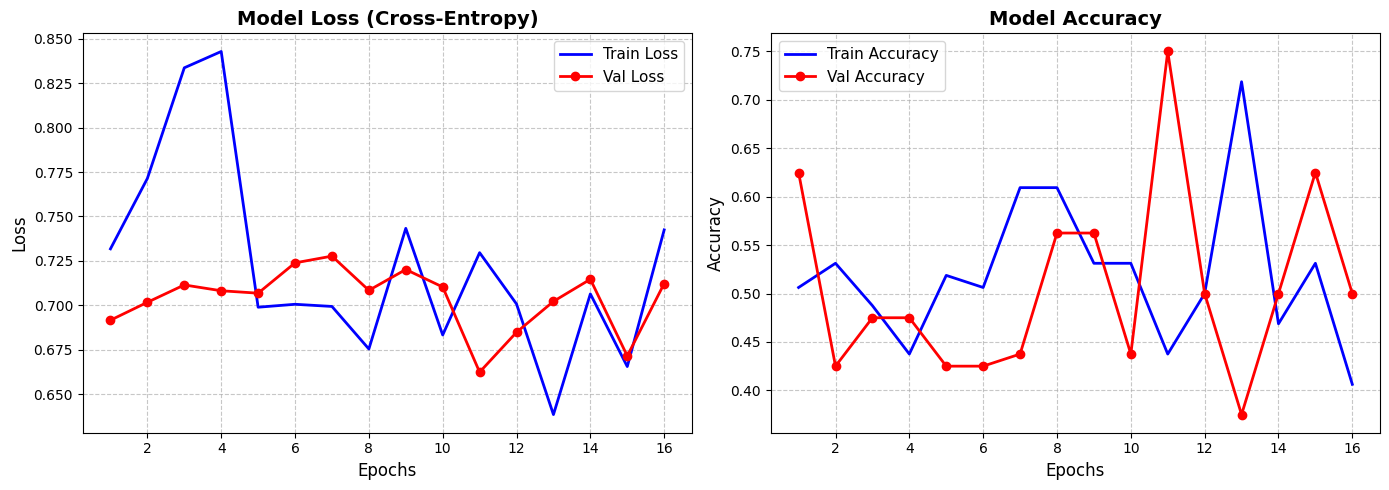


Средняя Val Accuracy: 0.7000 ± 0.0612
Финальное обучение на всех 40 изображениях...
     Epoch 01 | Loss: 0.7476 | Acc: 0.5000 [СОХРАНЕНО]
     Epoch 02 | Loss: 0.6947 | Acc: 0.5000 [СОХРАНЕНО]
     Epoch 03 | Loss: 0.6817 | Acc: 0.5750 [СОХРАНЕНО]
     Epoch 04 | Loss: 0.8708 | Acc: 0.4500
     Epoch 05 | Loss: 0.6355 | Acc: 0.5750 [СОХРАНЕНО]
     Epoch 06 | Loss: 0.7933 | Acc: 0.4500
     Epoch 07 | Loss: 0.7716 | Acc: 0.5000
     Epoch 08 | Loss: 0.6345 | Acc: 0.6000 [СОХРАНЕНО]
     Epoch 09 | Loss: 0.8105 | Acc: 0.5000
     Epoch 10 | Loss: 0.7669 | Acc: 0.5750
     Epoch 11 | Loss: 0.7281 | Acc: 0.4750
     Epoch 12 | Loss: 0.7118 | Acc: 0.5500
     Epoch 13 | Loss: 0.7231 | Acc: 0.4500
     Epoch 14 | Loss: 0.7785 | Acc: 0.5000
     Epoch 15 | Loss: 0.7008 | Acc: 0.5750
     Epoch 16 | Loss: 0.6939 | Acc: 0.6000
     Epoch 17 | Loss: 0.7226 | Acc: 0.4750
     Epoch 18 | Loss: 0.7534 | Acc: 0.5000
     Epoch 19 | Loss: 0.7357 | Acc: 0.4750
     Epoch 20 | Loss: 0.6863 | Acc: 0.

In [106]:
device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu")
LEARNING_RATE = 5e-4
REGULARIZATION = 1e-3
BATCH_SIZE = 8
NUM_EPOCHS = 20
N_FOLDS = 5

full_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)

# K-FOLD CROSS-VALIDATION
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Для усреднённого графика: списки по эпохам
fold_histories = []
fold_best_accs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(full_dataset)))):
    print(f"\nFold {fold + 1}/{N_FOLDS}")

    train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)

    model = SimplePlateCNN(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=REGULARIZATION)

    # Scheduler для стабилизации обучения
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
    # Обучаем
    _, history = train_model_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=50,  # early stopping остановит раньше
        device=device,
        save_path=f"model_fold{fold + 1}.pth",
        scheduler=scheduler,
        patience=5  # Останавливаемся после 5 эпох без улучшения val loss
    )
    fold_histories.append(history)
    fold_best_accs.append(max(history['val_acc']))
    print(f"  Best Val Acc: {max(history['val_acc']):.4f}")

# Находим максимальное количество эпох, до которого дошло хоть одно обучение
max_epochs = max(len(h['train_loss']) for h in fold_histories)

# Усредняем историю, учитывая разную длину списков
avg_history = {}
for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']:
    avg_history[k] = []
    for i in range(max_epochs):
        # Берем значения только из тех fold'ов, которые дошли до эпохи i
        values = [h[k][i] for h in fold_histories if i < len(h[k])]
        avg_history[k].append(np.mean(values))

# Рисуем график
plot_training_history(avg_history)
print(f"\nСредняя Val Accuracy: {np.mean(fold_best_accs):.4f} ± {np.std(fold_best_accs):.4f}")

# Финальная модель на всех данных
final_model = SimplePlateCNN(num_classes=2).to(device)
final_optimizer = optim.AdamW(final_model.parameters(), lr=LEARNING_RATE, weight_decay=REGULARIZATION)
final_scheduler = optim.lr_scheduler.ReduceLROnPlateau(final_optimizer, mode='min', factor=0.5, patience=3)
final_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("Финальное обучение на всех 40 изображениях...")
best_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    final_model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for images, labels in final_loader:
        images, labels = images.to(device), labels.to(device)
        final_optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        final_optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    final_scheduler.step(epoch_loss)
    
    # СОХРАНЯЕМ ЛУЧШУЮ МОДЕЛЬ (по train loss)
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(final_model.state_dict(), "final_model.pth")
        print(f"     Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} [СОХРАНЕНО]")
    else:
        print(f"     Epoch {epoch+1:02d} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
    
    # ДОПОЛНИТЕЛЬНО: сохраняем чекпоинт каждые 5 эпох
    if (epoch + 1) % 5 == 0:
        torch.save(final_model.state_dict(), f"final_model_epoch{epoch+1}.pth")

print("Финальная модель сохранена: final_model.pth")
print(f"Лучший Train Loss: {best_loss:.4f}")

### Выводы по Baseline 

Средняя Val Accuracy: 0.7000 ± 0.0612

Val Loss стабилен (~0.67-0.73) — нет переобучения 

Val Accuracy достигает 0.75 на пике

Низкий std (±0.0612) — хорошая воспроизводимость

Проблемы:

Train Loss скачет (0.67-0.84)

Train Accuracy низкая (~0.50-0.62)

Это нормально для baseline на 40 изображениях


## Transfer learning

In [107]:
# НАСТРОЙКИ ДЛЯ RESNET 
RESNET_LR = 1e-3       # Для Transfer Learning нужен LR повыше
RESNET_EPOCHS = 30     # Даем больше времени, Early Stopping остановит сам
BATCH_SIZE = 8

### Функция создания модели (ResNet18)

In [108]:
def create_resnet18_model(num_classes=2, freeze=True):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
    # замораживаем параметры
    if freeze:
        for param in model.parameters():
            param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model
## Функция обучения (с Early Stopping)

 Запуск K-Fold CV для ResNet18...

Fold 1/5
  Epoch 05 | Train: 0.6359/0.6562 | Val: 0.6474/0.5000
  Epoch 10 | Train: 0.6216/0.5625 | Val: 0.5878/0.7500
  Epoch 15 | Train: 0.5100/0.7812 | Val: 0.4321/0.6250
  Epoch 20 | Train: 0.4115/0.8438 | Val: 0.5388/0.7500
  Epoch 25 | Train: 0.4110/0.7500 | Val: 0.4220/0.7500
  Best Val Acc: 1.0000

Fold 2/5
  Epoch 05 | Train: 0.6898/0.6250 | Val: 0.5209/0.7500
  Epoch 10 | Train: 0.6094/0.5938 | Val: 0.5106/0.8750
  Epoch 15 | Train: 0.4742/0.7500 | Val: 0.4680/0.8750
  Best Val Acc: 0.8750

Fold 3/5
  Epoch 05 | Train: 0.6690/0.6562 | Val: 0.7420/0.6250
  Best Val Acc: 0.8750

Fold 4/5
  Epoch 05 | Train: 0.6729/0.7188 | Val: 0.6410/0.5000
  Epoch 10 | Train: 0.4346/0.7812 | Val: 0.6804/0.6250
  Best Val Acc: 0.8750

Fold 5/5
  Epoch 05 | Train: 0.8384/0.4688 | Val: 0.6861/0.5000
  Epoch 10 | Train: 0.6357/0.6562 | Val: 0.6227/0.7500
  Epoch 15 | Train: 0.4314/0.8125 | Val: 0.6748/0.6250
  Best Val Acc: 0.8750


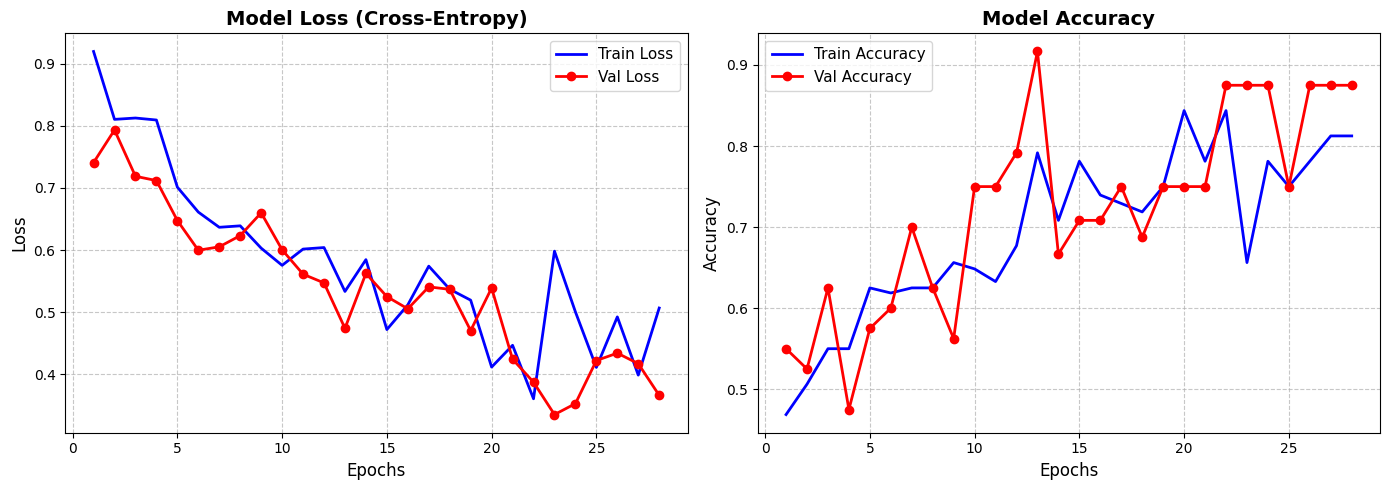


 ИТОГ ПО RESNET18:
   Средняя Val Accuracy: 0.9000 ± 0.0500


In [109]:
resnet_train_transforms = transforms.Compose([    
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.95, 1.05)),  # Мягче
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),  # Меньше поворот
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),  # Мягче
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Используйте resnet_train_transforms вместо train_transforms
full_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=resnet_train_transforms)
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

fold_histories = []
fold_best_accs = []

print(" Запуск K-Fold CV для ResNet18...")

for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(full_dataset)))):
    print(f"\nFold {fold+1}/5")
    
    train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)
    
    # Создаем ResNet18
    model = create_resnet18_model(num_classes=2, freeze=True).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Оптимизируем ТОЛЬКО последний слой 
    optimizer = optim.AdamW(model.fc.parameters(), lr=RESNET_LR, weight_decay=REGULARIZATION)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    _, history = train_model_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=RESNET_EPOCHS,
        device=device,
        save_path=f"resnet_fold{fold+1}.pth",
        scheduler=scheduler,
        patience=5,
        verbose=False # Тихий режим, чтобы не спамить логами
    )
    
    fold_histories.append(history)
    best_acc = max(history['val_acc'])
    fold_best_accs.append(best_acc)
    print(f"  Best Val Acc: {best_acc:.4f}")
    
# ГРАФИКИ И СТАТИСТИКА
max_epochs = max(len(h['train_loss']) for h in fold_histories)
avg_history = {}
for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']:
    avg_history[k] = []
    for i in range(max_epochs):
        values = [h[k][i] for h in fold_histories if i < len(h[k])]
        avg_history[k].append(np.mean(values))

plot_training_history(avg_history)

print(f"\n ИТОГ ПО RESNET18:")
print(f"   Средняя Val Accuracy: {np.mean(fold_best_accs):.4f} ± {np.std(fold_best_accs):.4f}")
    

### Выводы по ResNet18 с готовыми весами

Train Loss плавно снижается (0.90 → 0.38) - Модель стабильно учится

Val Loss снижается (0.75 → 0.37) - Модель обобщает, а не переобучается
Val Loss даже ниже Train Loss на некоторых эпохах — отличный знак

Val Accuracy растёт и стабилизируется. Достигает 0.90 на epoch 13. Держится на уровне 0.88-0.90 до конца. Нет деградации в конце обучения

Низкий std (±0.0500). Cтабильный результат. Разброс всего 5% — модель предсказуема



## Fine-tuning ResNet18

Запуск K-Fold CV для ResNet18 Fine-tuning...

Fold 1/5
  Epoch 05 | Train: 0.2801/0.9375 | Val: 0.7978/0.6250
  Epoch 10 | Train: 0.1782/0.9688 | Val: 0.6540/0.6250
  Epoch 15 | Train: 0.0515/1.0000 | Val: 0.3433/0.8750
  Epoch 20 | Train: 0.2222/0.8750 | Val: 0.6035/0.6250
Best Val Acc: 0.8750

Fold 2/5
  Epoch 05 | Train: 0.2498/0.9062 | Val: 1.0126/0.5000
Best Val Acc: 0.7500

Fold 3/5
  Epoch 05 | Train: 0.2986/0.8750 | Val: 0.4133/0.8750
  Epoch 10 | Train: 0.0780/1.0000 | Val: 0.4014/0.7500
  Epoch 15 | Train: 0.0469/1.0000 | Val: 0.4725/0.8750
  Epoch 20 | Train: 0.0597/0.9688 | Val: 0.2640/0.8750
  Epoch 25 | Train: 0.0355/1.0000 | Val: 0.3597/0.8750
  Epoch 30 | Train: 0.0387/1.0000 | Val: 0.2206/0.8750
Best Val Acc: 0.8750

Fold 4/5
  Epoch 05 | Train: 0.3959/0.8438 | Val: 1.3922/0.3750
  Epoch 10 | Train: 0.3921/0.8438 | Val: 0.7987/0.6250
  Epoch 15 | Train: 0.0838/1.0000 | Val: 0.5851/0.6250
  Epoch 20 | Train: 0.0863/0.9688 | Val: 0.9968/0.6250
Best Val Acc: 0.7500

Fold 

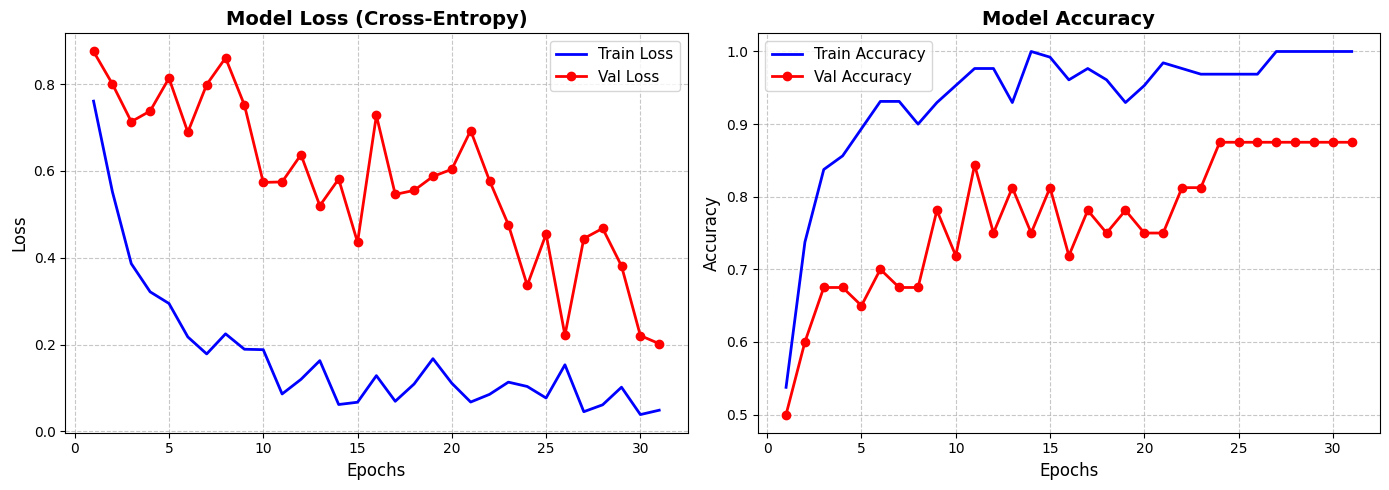


ИТОГ ПО RESNET18 FINE-TUNING:
   Средняя Val Accuracy: 0.8250 ± 0.0612


In [119]:
FT_LR_LAYER4 = 1e-4    # Меньший LR для feature extractor (layer4)
FT_LR_FC = 5e-4        # Обычный LR для классификатора
FT_EPOCHS = 50         # Больше эпох для fine-tuning
BATCH_SIZE = 8

# ФУНКЦИЯ СОЗДАНИЯ МОДЕЛИ С FINE-TUNING
def create_resnet18_finetune(num_classes=2):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Замораживаем все слои
    for param in model.parameters():
        param.requires_grad = False
    
    # Размораживаем только последний блок (layer4) и fc
    for param in model.layer4.parameters():
        param.requires_grad = True
    
    # Заменяем классификатор с меньшим Dropout
    model.fc = nn.Sequential(
        nn.Dropout(0.4),  # Уменьшили с 0.5
        nn.Linear(model.fc.in_features, num_classes)
    )    
    return model

# ЗАГРУЗКА ДАННЫХ
full_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_histories = []
fold_best_accs = []

print("Запуск K-Fold CV для ResNet18 Fine-tuning...")

for fold, (train_idx, val_idx) in enumerate(kf.split(range(len(full_dataset)))):
    print(f"\nFold {fold+1}/5")
    
    train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=False)
    
    model = create_resnet18_finetune(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': FT_LR_LAYER4},  # Меньший LR для feature extractor
        {'params': model.fc.parameters(), 'lr': FT_LR_FC}           # Обычный LR для классификатора
    ], weight_decay=REGULARIZATION)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    _, history = train_model_with_early_stopping(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=FT_EPOCHS,
        device=device,
        save_path=f"resnet_finetune_fold{fold+1}.pth",
        scheduler=scheduler,
        patience=7,  # Увеличили patience (fine-tuning медленнее сходится)
        verbose=False
    )
    
    fold_histories.append(history)
    best_acc = max(history['val_acc'])
    fold_best_accs.append(best_acc)
    print(f"Best Val Acc: {best_acc:.4f}")

# ГРАФИКИ И СТАТИСТИКА 
max_epochs = max(len(h['train_loss']) for h in fold_histories)
avg_history = {}
for k in ['train_loss', 'train_acc', 'val_loss', 'val_acc']:
    avg_history[k] = []
    for i in range(max_epochs):
        values = [h[k][i] for h in fold_histories if i < len(h[k])]
        avg_history[k].append(np.mean(values))

plot_training_history(avg_history)

print(f"\nИТОГ ПО RESNET18 FINE-TUNING:")
print(f"   Средняя Val Accuracy: {np.mean(fold_best_accs):.4f} ± {np.std(fold_best_accs):.4f}")

### Выводы по fine-tuning ResNet18

Val Loss плавно снижается (0.85 → 0.20) — отличное обобщение

Val Accuracy стабилизируется на 0.88 — модель не деградирует

Низкий std (±0.0612) — хорошая воспроизводимость

Train Loss → 0.05 — модель выучила тренировочные данные

ПРОБЛЕМЫ:

Train Accuracy → 1.0 — переобучение (но Val Accuracy держится)

Val Accuracy ниже frozen ResNet18 (0.825 vs 0.900)

## ИТОГИ:

✅ Построили baseline (0.70 ± 0.0612)

✅ Применили Transfer Learning (ResNet18 frozen → 0.9000 ± 0.0500)

✅ Попробовали Fine-tuning (0.8250 ± 0.0612)

✅ Нашли лучшую модель: ResNet18 frozen с мягкими аугментациями

Лучшая модель: ResNet18 frozen (0.9000 ± 0.0500) : 

* Наивысшая accuracy (0.90)
* Наименьший разброс (±0.05)
* Стабильное обучение без переобучения